In [1]:
# These modules are required for the data reduction.
from dysh.fits import GBTFITSLoad
from dysh.log import init_logging
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(example="nod3")

15:58:27.164 I Resolving example=nod3 -> nod-W/data/AGBT15B_244_07.raw.vegas.trim.fits


15:58:27.165 I url: http://www.gb.nrao.edu/dysh//example_data/nod-W/data/AGBT15B_244_07.raw.vegas.trim.fits


Odd-1, did not find /bigdisk/data/gbt/dysh_data/example_data/nod-W/data/AGBT15B_244_07.raw.vegas.trim.fits
AGBT15B_244_07.raw.vegas.trim.fits already downloaded


In [4]:
sdfits = GBTFITSLoad(filename)
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
130,M82,0.0,CALSEQ,1,87.645,4,2,3,2,334.3782,46.5595
131,M82,0.0,Nod,1,87.645,4,2,1,2,334.3555,46.4977
132,M82,0.0,Nod,2,87.645,4,2,1,2,334.4400,46.3994
133,M82,0.0,Nod,1,87.645,4,2,1,2,334.2819,46.2979
134,M82,0.0,Nod,2,87.645,4,2,1,2,334.3704,46.1996
135,M82,0.0,Nod,1,87.645,4,2,1,2,334.2152,46.0993
136,M82,0.0,Nod,2,87.645,4,2,1,2,334.3061,46.0009
137,M82,0.0,Nod,1,87.645,4,2,1,2,334.1520,45.9003
138,M82,0.0,Nod,2,87.645,4,2,1,2,334.2438,45.8002
139,M82,0.0,Nod,1,87.645,4,2,1,2,334.0929,45.6982


In [5]:
fdnums = sdfits.udata("FDNUM") # Feeds.
ifnums = sdfits.udata("IFNUM") # Spectral windows.
plnums = sdfits.udata("PLNUM") # Polarizations. 
cscans = [130, 141] # calseq scan numbers.

# Create an array to store the system temperature for each combination.
tsys = np.empty((len(cscans), len(fdnums), len(plnums), len(ifnums)), dtype=float)

# Loop over the combinations.
for s,scan in enumerate(cscans):
    for f,fdnum in enumerate(fdnums):
        for p,plnum in enumerate(plnums):
            for i,ifnum in enumerate(ifnums):
                tsys[s,f,p,i], _ = sdfits.calseq(scan=scan, fdnum=fdnum, plnum=plnum, ifnum=ifnum)

In [6]:
np.diff(tsys, axis=0)/np.mean(tsys, axis=0)*100

array([[[[2.07996041, 2.02069088, 2.01024058, 1.98262645],
         [2.23058483, 2.34203283, 1.97049038, 1.88568961]],

        [[2.18532318, 2.10310376, 2.07058868, 2.0877803 ],
         [2.25814277, 2.1933681 , 2.21046665, 2.12652005]]]])

In [7]:
tsys = np.mean(tsys, axis=0)

In [8]:
nod_ta = np.empty((len(plnums), len(ifnums)), dtype=object)
nod_scans = [131, 133, 135, 137, 139]

for p,plnum in enumerate(plnums):
    for i,ifnum in enumerate(ifnums):
        # Extract the system temperature for both feeds for this polarization and spectral window.
        t_sys = [[t] for t in tsys[:,p,i]]
        # Call the calibration function.
        nod_ta[p,i] = sdfits.getnod(scan=nod_scans, ifnum=ifnum, plnum=plnum, t_sys=t_sys).timeaverage()

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


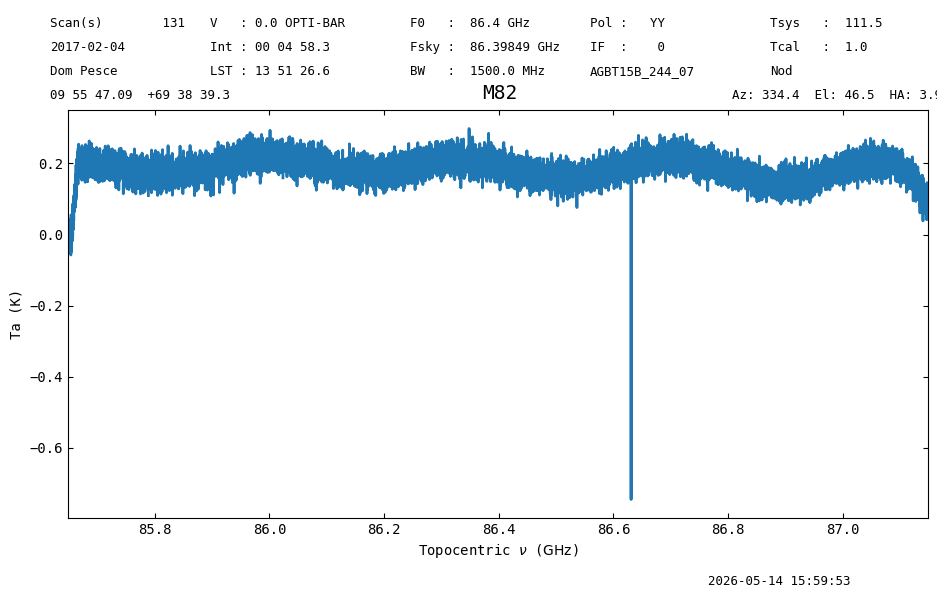

In [9]:
nod_ta[0,0].plot();

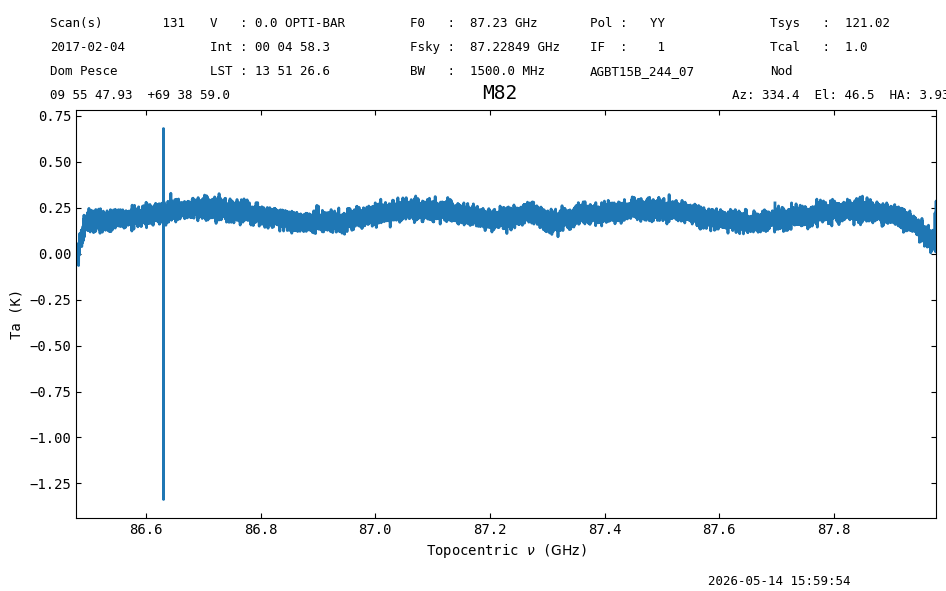

In [10]:
nod_ta[0,1].plot();

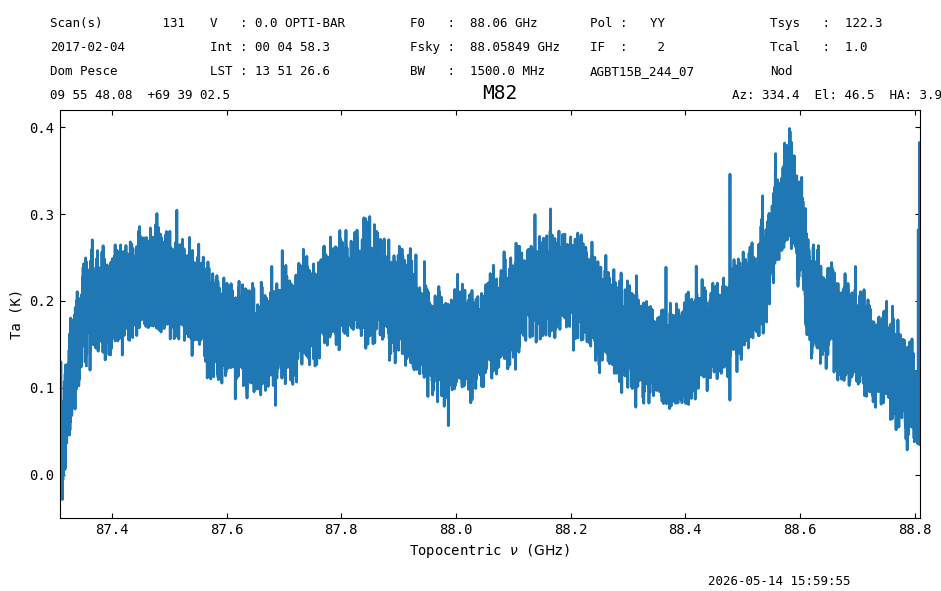

In [11]:
nod_ta[0,2].plot();

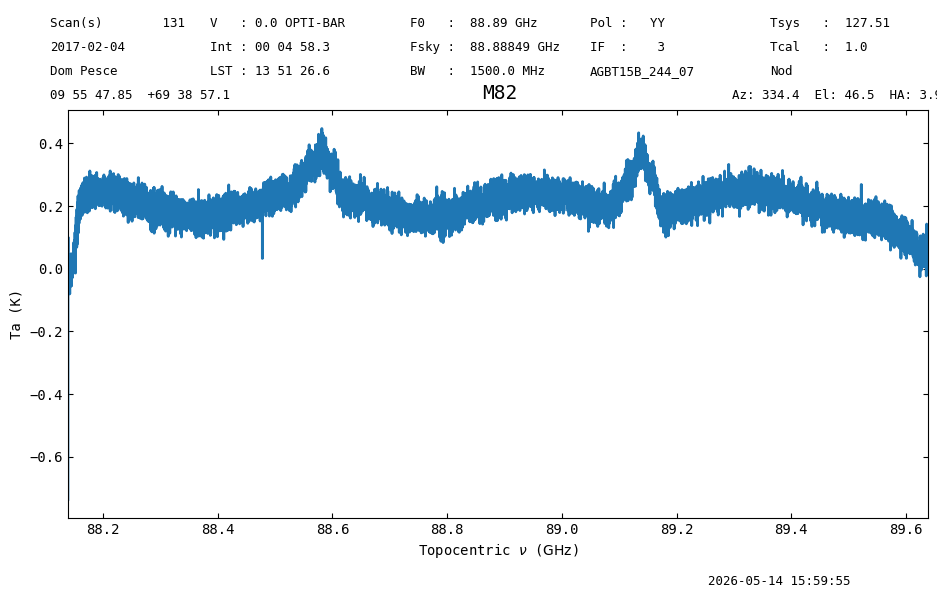

In [12]:
nod_ta[0,3].plot();

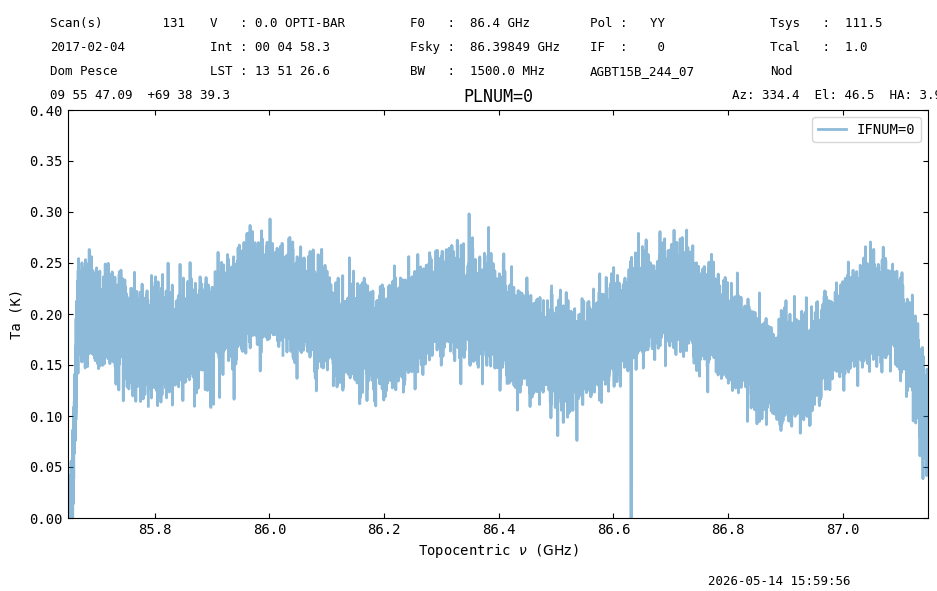

In [13]:
p0 = nod_ta[0,0].plot(ymin=0.0, ymax=0.4, xaxis_unit="GHz", alpha=0.5, 
                      title="PLNUM=0", label=f"IFNUM={nod_ta[0,0].meta['IFNUM']}")
pl0_specs = nod_ta[0,1:]
p0.oshow(pl0_specs, alpha=[0.5]*len(pl0_specs), 
         label=[f"IFNUM={s.meta['IFNUM']}" for s in pl0_specs])

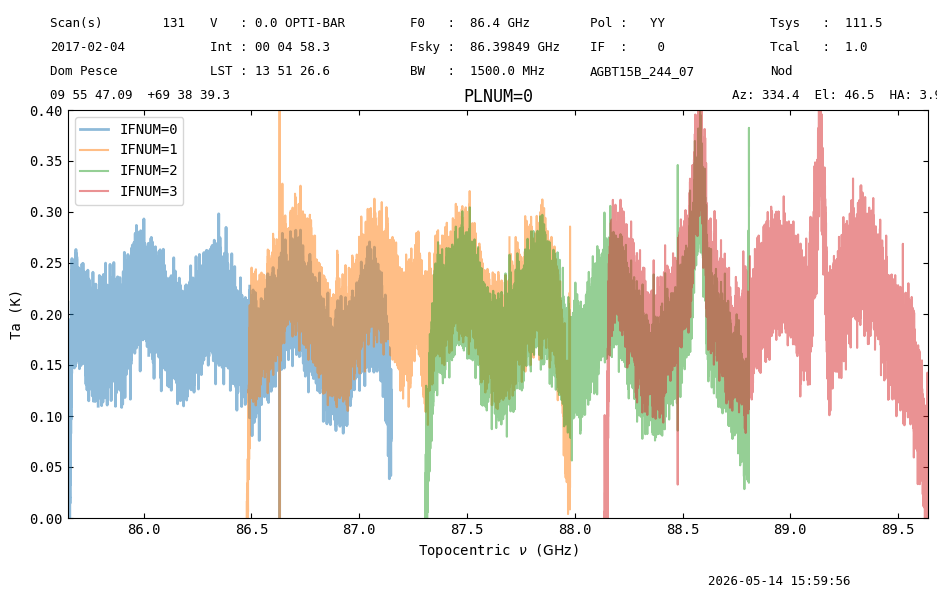

In [14]:
p0.show() # This should only be needed for the documentation.

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


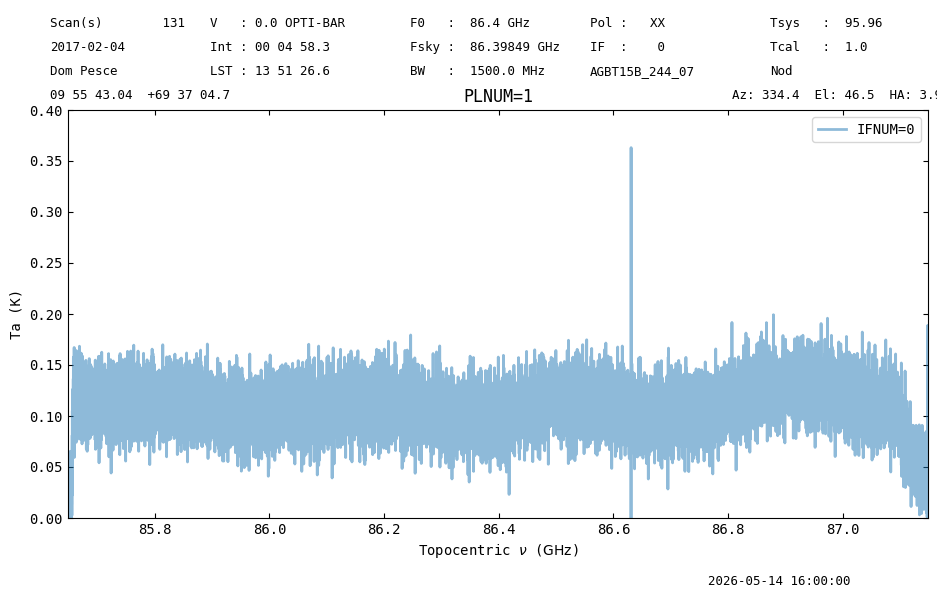

In [15]:
p1 = nod_ta[1,0].plot(ymin=0.0, ymax=0.4, xaxis_unit="GHz", alpha=0.5, 
                      title="PLNUM=1", label=f"IFNUM={nod_ta[1,0].meta['IFNUM']}")
pl1_specs = nod_ta[1,1:]
p1.oshow(pl1_specs, alpha=[0.5]*len(pl0_specs), 
         label=[f"IFNUM={s.meta['IFNUM']}" for s in pl1_specs])

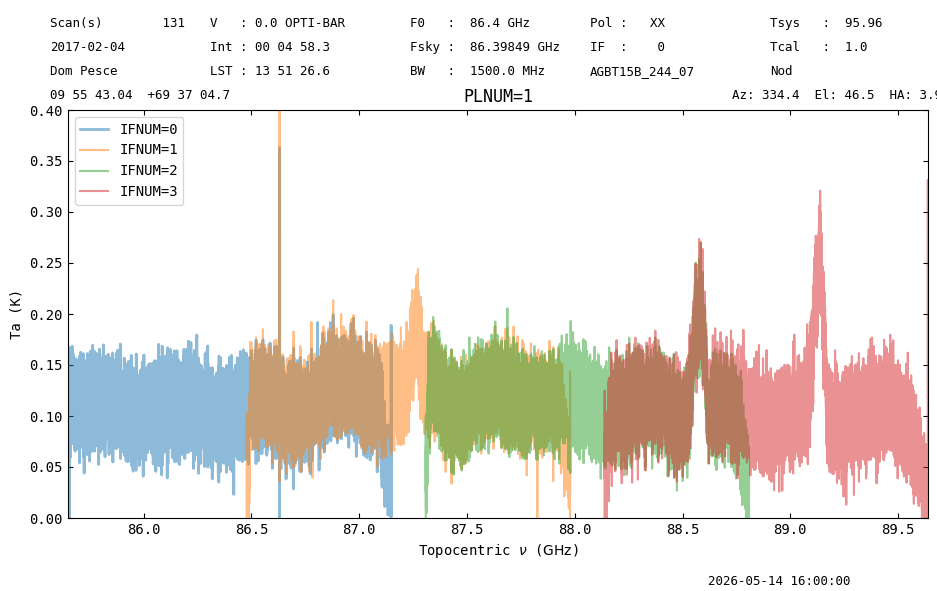

In [16]:
p1.show() # This should only be needed for the documentation.

In [17]:
nod_ta_lines = nod_ta[:,[1,2,3]]

In [18]:
# Define baseline parameters.
order = 15
model = "poly"
edge = 500
exclude = {1: [(nod_ta_lines[0,0].spectral_axis.quantity.min().to("GHz"), 
                nod_ta_lines[0,0].spectral_axis.quantity[edge].to("GHz")),
               (87.2*u.GHz, 87.3*u.GHz),
               (nod_ta_lines[0,0].spectral_axis.quantity[-edge].to("GHz"), 
                nod_ta_lines[0,0].spectral_axis.quantity.max().to("GHz")),
              ],
           2: [(nod_ta_lines[0,1].spectral_axis.quantity.min().to("GHz"), 
                nod_ta_lines[0,1].spectral_axis.quantity[edge].to("GHz")),
               (88.5*u.GHz, 88.65*u.GHz), 
               (nod_ta_lines[0,1].spectral_axis.quantity[-edge].to("GHz"), 
                nod_ta_lines[0,1].spectral_axis.quantity.max().to("GHz"))
              ],
           3: [(nod_ta_lines[0,2].spectral_axis.quantity.min().to("GHz"), 
                nod_ta_lines[0,2].spectral_axis.quantity[edge].to("GHz")),
               (88.5*u.GHz, 88.7*u.GHz), 
               (89*u.GHz, 89.23*u.GHz),
               (nod_ta_lines[0,2].spectral_axis.quantity[-edge].to("GHz"), 
                nod_ta_lines[0,2].spectral_axis.quantity.max().to("GHz"))
              ],
          }

In [19]:
# Loop over spectra and remove the baseline.
for nod_ta_lines_p in nod_ta_lines:
    for spec in nod_ta_lines_p:
        spec.baseline(order, model=model, exclude=exclude[spec.meta["IFNUM"]], remove=True)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


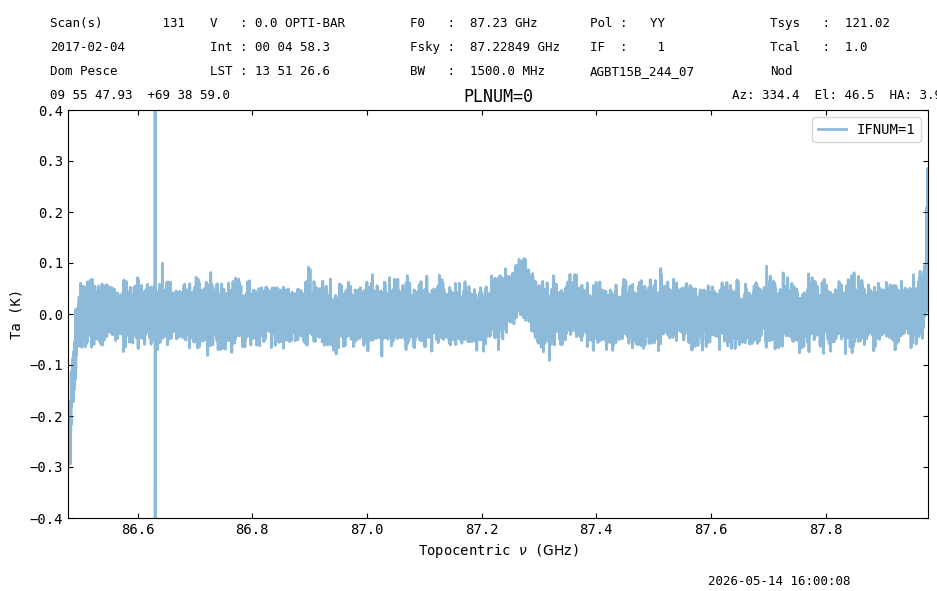

In [20]:
p0 = nod_ta_lines[0,0].plot(ymin=-0.4, ymax=0.4, xaxis_unit="GHz", alpha=0.5, 
                      title="PLNUM=0", label=f"IFNUM={nod_ta_lines[0,0].meta['IFNUM']}")
pl0_specs = nod_ta_lines[0,1:]
p0.oshow(pl0_specs, alpha=[0.5]*len(pl0_specs), 
         label=[f"IFNUM={s.meta['IFNUM']}" for s in pl0_specs])

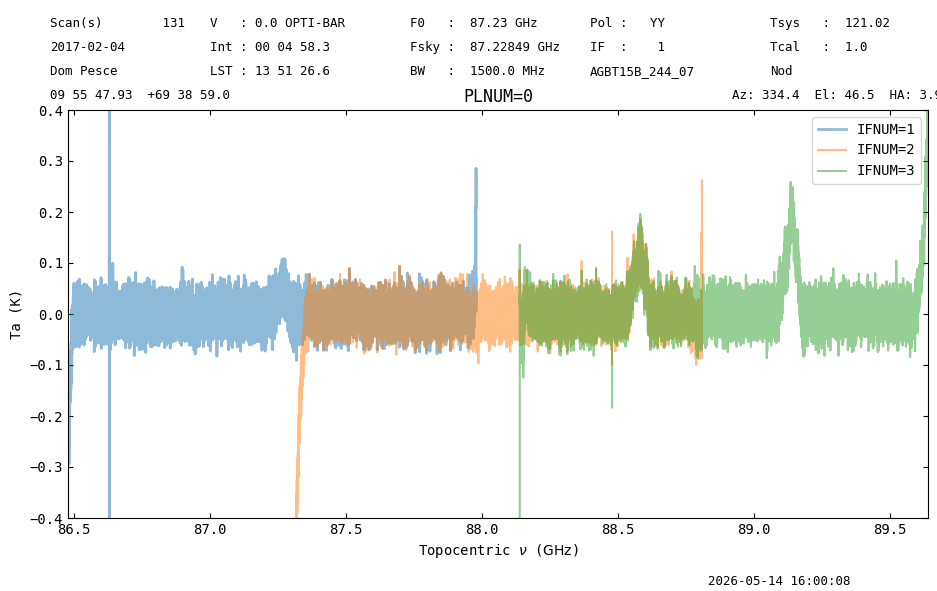

In [21]:
p0.show() # This should only be needed for the documentation.

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


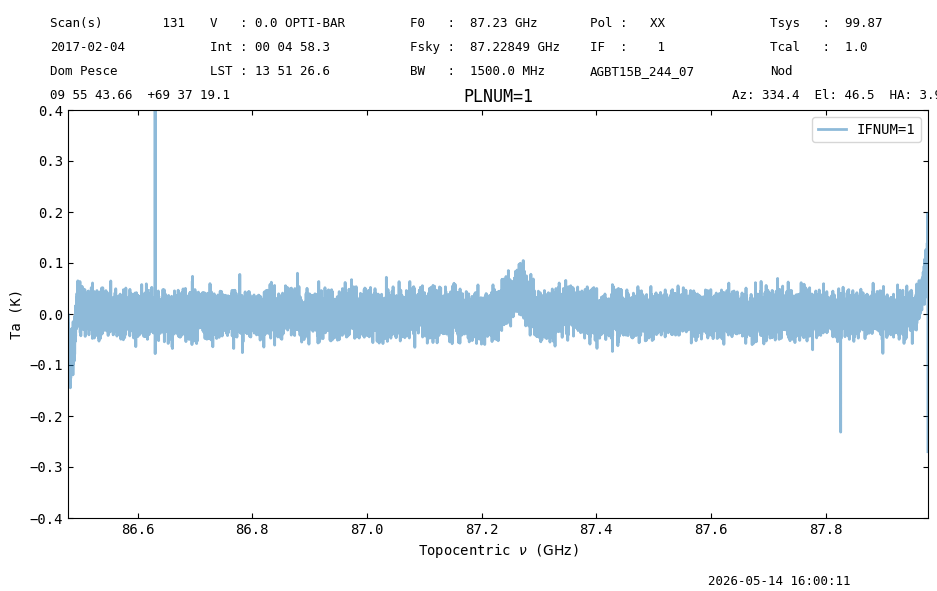

In [22]:
p1 = nod_ta_lines[1,0].plot(ymin=-0.4, ymax=0.4, xaxis_unit="GHz", alpha=0.5, 
                      title="PLNUM=1", label=f"IFNUM={nod_ta_lines[0,0].meta['IFNUM']}")
pl1_specs = nod_ta_lines[1,1:]
p1.oshow(pl1_specs, alpha=[0.5]*len(pl1_specs), 
         label=[f"IFNUM={s.meta['IFNUM']}" for s in pl1_specs])

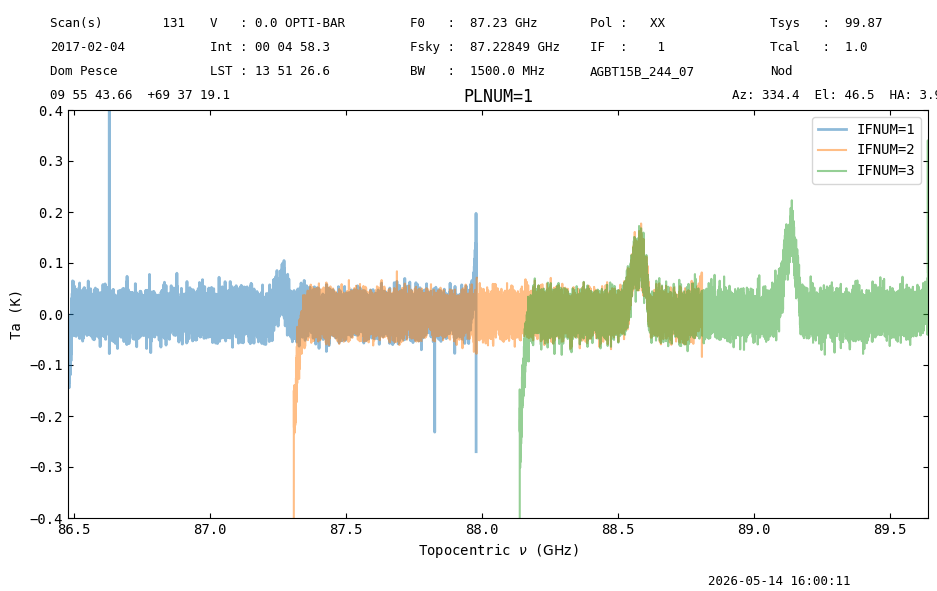

In [23]:
p1.show() # This should only be needed for the documentation.

In [24]:
tau = {0: 6.28488304e-02,
       1: 5.99070412e-02,
       2: 5.73315943e-02,
       3: 5.51805677e-02
      }

In [25]:
nod_ta_star = np.empty((len(plnums), len(ifnums)), dtype=object)
nod_scans = [131, 133, 135, 137, 139]

for p,plnum in enumerate(plnums):
    for i,ifnum in enumerate(ifnums):
        # Extract the system temperature for both feeds for this polarization and spectral window.
        t_sys = [[t] for t in tsys[:,p,i]]
        # Call the calibration function.
        nod_ta_star[p,i] = sdfits.getnod(scan=nod_scans, ifnum=ifnum, plnum=plnum, 
                                         t_sys=t_sys, 
                                         zenith_opacity=tau[ifnum],
                                         units="Ta*"
                                        ).timeaverage()

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


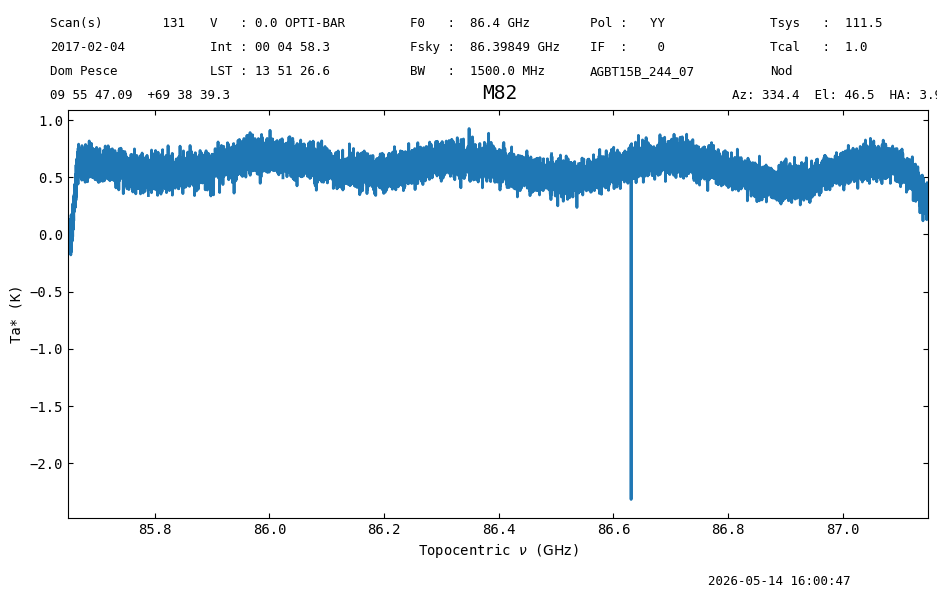

In [26]:
nod_ta_star[0,0].plot();

In [27]:
nod_ta_star_lines = nod_ta_star[:,[1,2,3]]
for nod_ta_star_lines_p in nod_ta_star_lines:
    for spec in nod_ta_star_lines_p:
        spec.baseline(order, model=model, exclude=exclude[spec.meta["IFNUM"]], remove=True)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


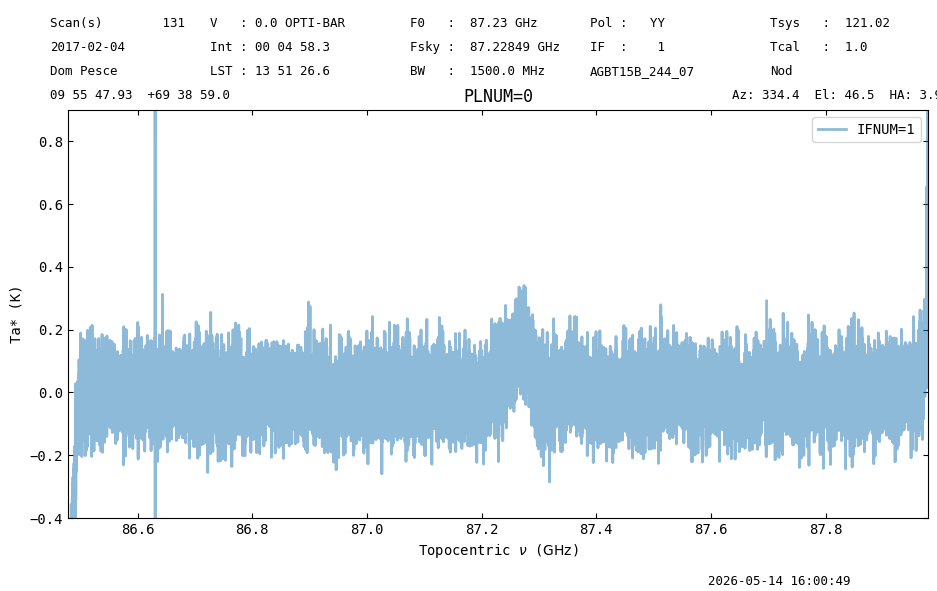

In [28]:
p0 = nod_ta_star_lines[0,0].plot(ymin=-0.4, ymax=0.9, xaxis_unit="GHz", alpha=0.5, 
                      title="PLNUM=0", label=f"IFNUM={nod_ta_star_lines[0,0].meta['IFNUM']}")
pl0_specs = nod_ta_star_lines[0,1:]
p0.oshow(pl0_specs, alpha=[0.5]*len(pl0_specs), 
         label=[f"IFNUM={s.meta['IFNUM']}" for s in pl0_specs])

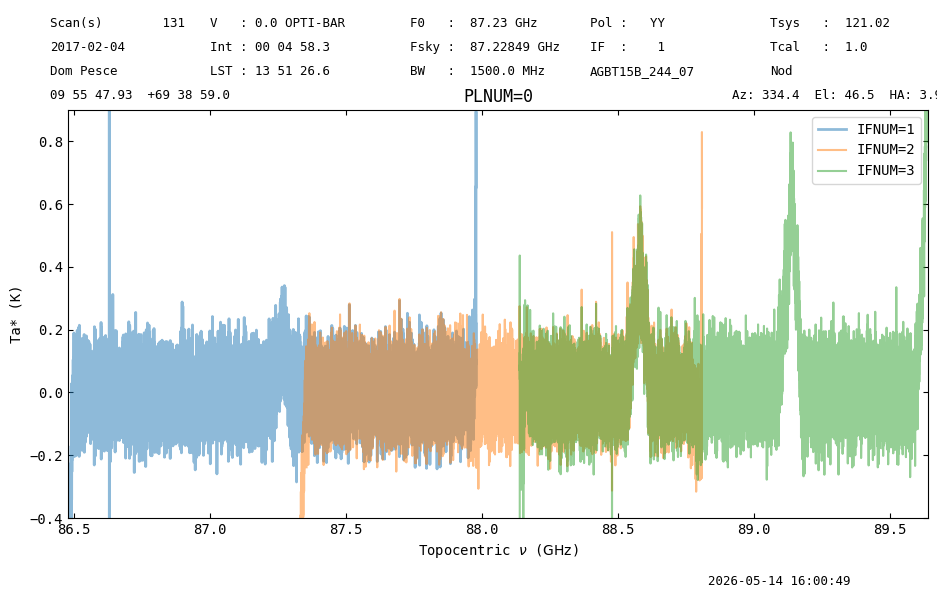

In [29]:
p0.show() # This should only be needed for the documentation.

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


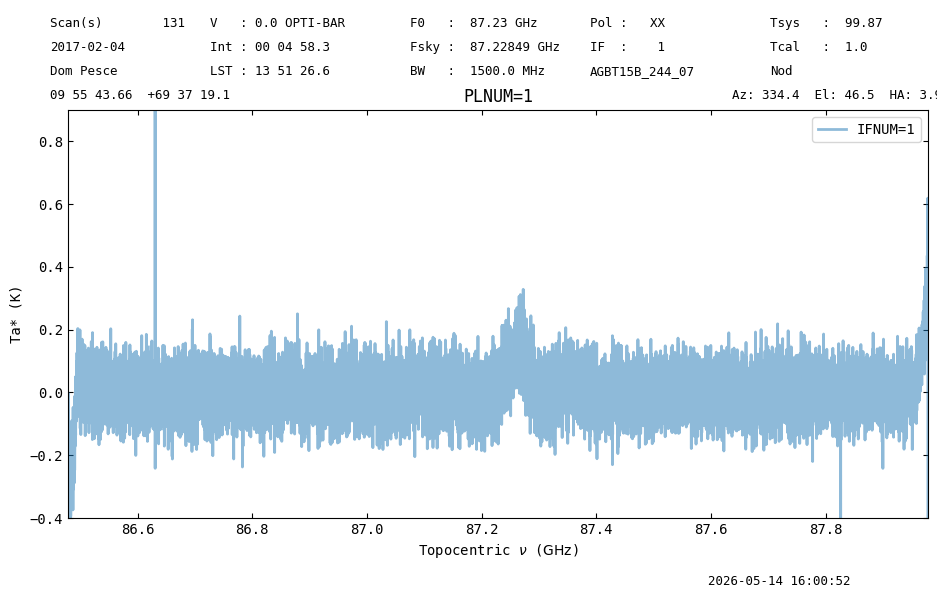

In [30]:
p1 = nod_ta_star_lines[1,0].plot(ymin=-0.4, ymax=0.9, xaxis_unit="GHz", alpha=0.5, 
                      title="PLNUM=1", label=f"IFNUM={nod_ta_star_lines[1,0].meta['IFNUM']}")
pl1_specs = nod_ta_star_lines[1,1:]
p1.oshow(pl1_specs, alpha=[0.5]*len(pl1_specs), 
         label=[f"IFNUM={s.meta['IFNUM']}" for s in pl1_specs])

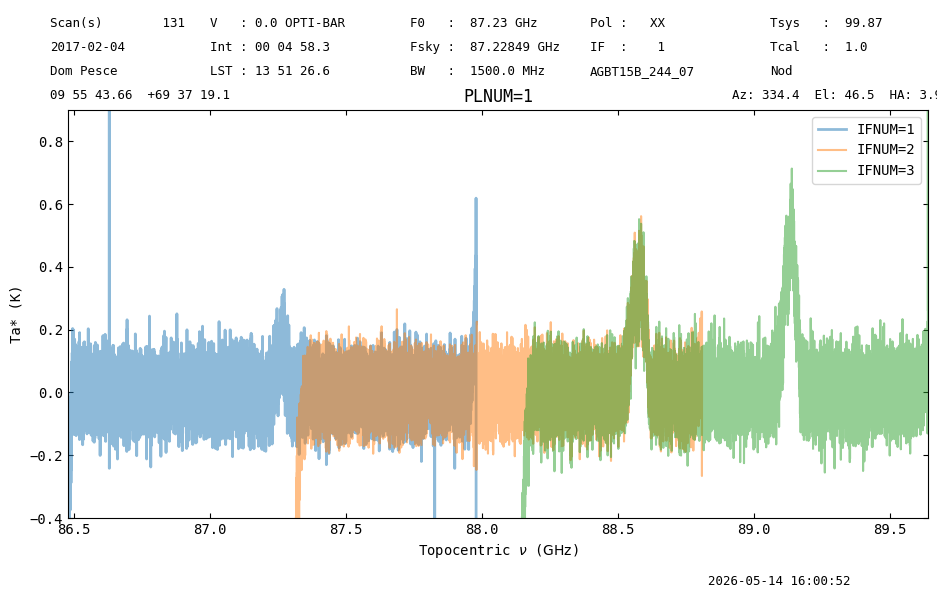

In [31]:
p1.show() # This should only be needed for the documentation.

In [32]:
ta_star_pol_ave = np.empty(nod_ta_star_lines.shape[1], dtype=object)

for i in range(nod_ta_star_lines.shape[1]):
    ta_star_pol_ave[i] = nod_ta_star_lines[0,i].average(nod_ta_star_lines[1,i])

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


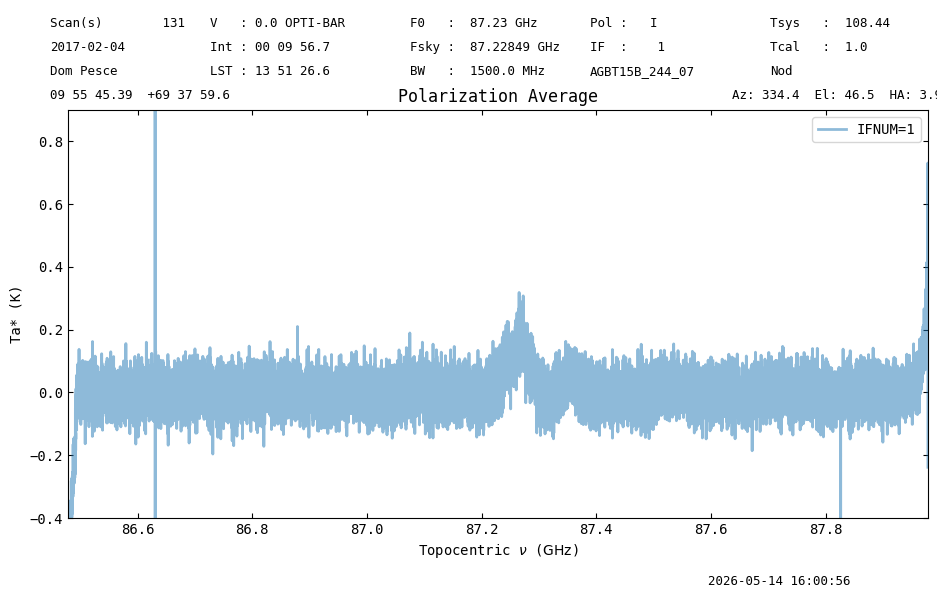

In [33]:
pa = ta_star_pol_ave[0].plot(ymin=-0.4, ymax=0.9, xaxis_unit="GHz", alpha=0.5, 
                      title="Polarization Average", label=f"IFNUM={nod_ta_star_lines[0,0].meta['IFNUM']}")
avg_specs = ta_star_pol_ave[1:]
pa.oshow(avg_specs, alpha=[0.5]*len(avg_specs), 
         label=[f"IFNUM={s.meta['IFNUM']}" for s in avg_specs])

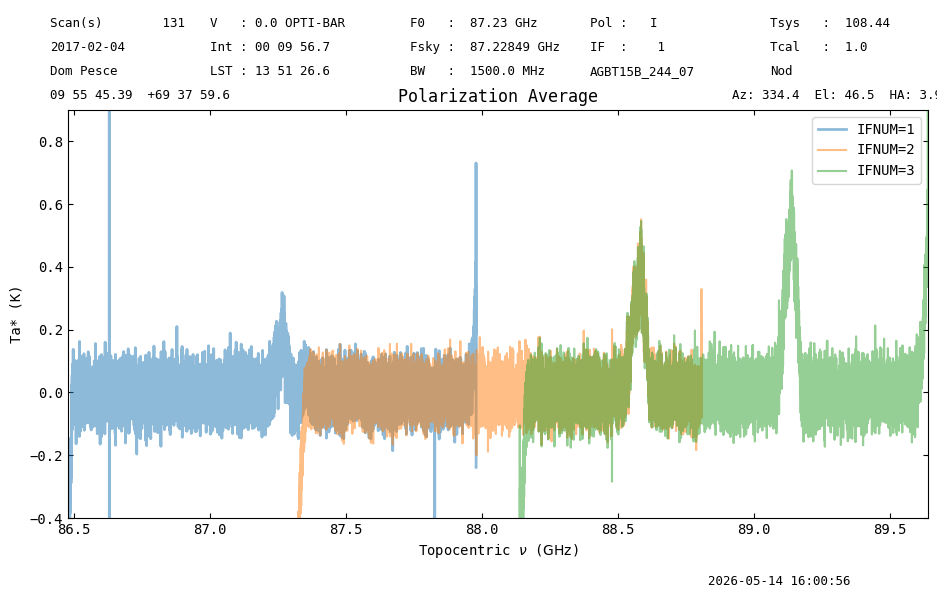

In [34]:
pa.show() # This should only be needed for the documentation.

In [35]:
for spec in ta_star_pol_ave:
    fnm_out = output_dir / f"M82_ifnum_{spec.meta['IFNUM']}_polavg.fits"
    spec.write(fnm_out, format="fits", overwrite=True)

In [36]:
from dysh.spectra import Spectrum
read_spec = Spectrum.read(output_dir / "M82_ifnum_1_polavg.fits", format="fits")

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


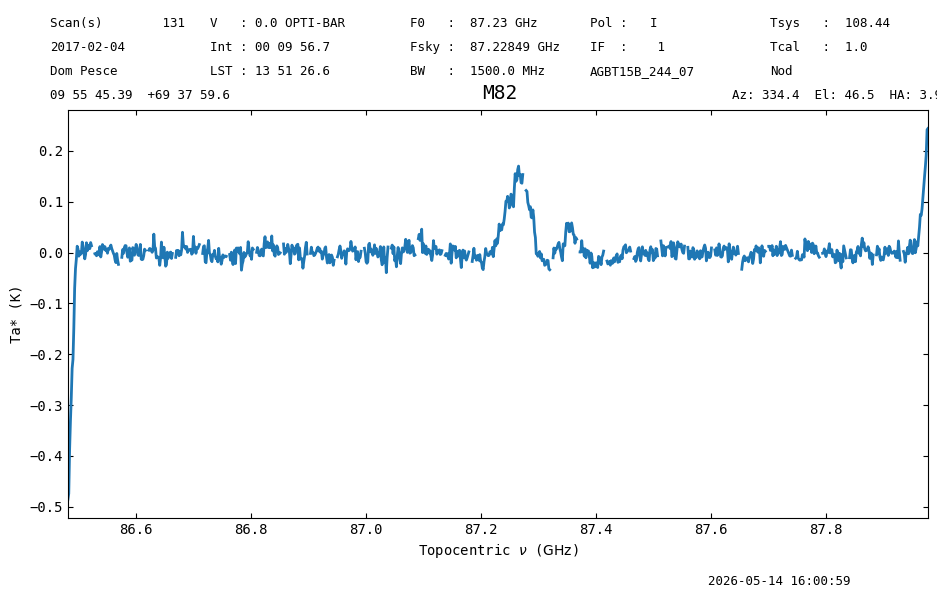

In [37]:
read_spec_smo = read_spec.smooth("gauss", 16)
read_spec_smo.plot()

In [38]:
read_spec.history

['2026-05-14T16:00:59-0700 - DYSH v1.1.0 : dysh.spectra.spectrum.Spectrum.__init__(flux=<Quantity [        nan, -0.38167784, -0.42788408, ...,  0.29981571,             0.28108434, -0.23835116] K>,wcs=WCS Keywords  Number of WCS axes: 4 CTYPE : \'FREQ\' \'RA\' \'DEC\' \'STOKES\' CUNIT : \'Hz\' \'deg\' \'deg\' \'\' CRVAL : 87228489084.0 148.93912271827946 69.63322176771119 1.0 CRPIX : 8193.0 0.0 0.0 0.0 PC1_1 PC1_2 PC1_3 PC1_4  : 1.0 0.0 0.0 0.0 PC2_1 PC2_2 PC2_3 PC2_4  : 0.0 1.0 0.0 0.0 PC3_1 PC3_2 PC3_3 PC3_4  : 0.0 0.0 1.0 0.0 PC4_1 PC4_2 PC4_3 PC4_4  : 0.0 0.0 0.0 1.0 CDELT : 91552.734375 1.0 1.0 1.0 NAXIS : 16384  0  0  0,meta={\'OBJECT\': \'M82\', \'BANDWID\': 1500000000.0, \'DATE-OBS\': \'2017-02-04T10:11:43.00\', \'DURATION\': 609.7817230224609, \'EXPOSURE\': 596.6629532243182, \'TSYS\': 108.43737062628821, \'CTYPE1\': \'FREQ-OBS\', \'CRVAL1\': 87228489084.0, \'CRPIX1\': 8193.0, \'CDELT1\': 91552.734375, \'CTYPE2\': \'RA\', \'CRVAL2\': 148.93912271827946, \'CTYPE3\': \'DEC\', \'C

In [39]:
from astropy.io import fits
hdu = fits.open(output_dir / "M82_ifnum_1_polavg.fits")
hdu

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7dca525922d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7dca54bd6030>]

In [40]:
header = hdu[1].header
data = hdu[1].data
hdu.close() # Close the file for now.

In [41]:
header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   48 / length of dimension 1                          
NAXIS2  =                16384 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    6 / number of table fields                         
TTYPE1  = 'spectral_axis'                                                       
TFORM1  = 'D       '                                                            
TUNIT1  = 'Hz      '                                                            
TTYPE2  = 'flux    '                                                            
TFORM2  = 'D       '        

In [42]:
header["HISTORY"]

2026-05-14T15:58:27 - Project ID: AGBT15B_244_07
2026-05-14T15:58:27-0700 - DYSH v1.1.0 : dysh.fits.gbtfitsload.GBTFITSLo
ad.__init__(PosixPath('/bigdisk/data/gbt/dysh_data/example_data/AGBT15B_
244_07.raw.vegas.trim.fits'),)
2026-05-14T15:58:27-0700 - DYSH v1.1.0 : dysh.fits.gbtfitsload.GBTFITSLo
ad.apply_flags()
2026-05-14T15:58:27-0700 - DYSH v1.1.0 : dysh.fits.gbtfitsload.GBTFITSLo
ad.flag_vegas_spurs(selection=  OBJECT       BANDWID                DATE
-OBS  DURATION  EXPOSURE  TSYS  \ 0    M82  1.500000e+09  2017-02-04T10:
10:45.00  9.996425  9.939025   1.0                TDIM7  TUNIT7    CTYPE
1        CRVAL1  ...          GUIDEVER  \ 0  (16384,1,1,1)  Counts  FREQ
-OBS  8.639849e+10  ...  GBTIDL ver2.10.1        FITSVER      EXTNAME  C
TYPE4 FITSINDEX                 UTC  CHAN    PROC  \ 0      1.9  SINGLE
DISH  STOKES         0 2017-02-04 10:10:45  None  CALSEQ       OBSTYPE
SUBOBSMODE   0    NONE     TPNOCAL    [1 rows x 99 columns],)
2026-05-14T15:58:29-0700 - DYSH v1.1.0 : 

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


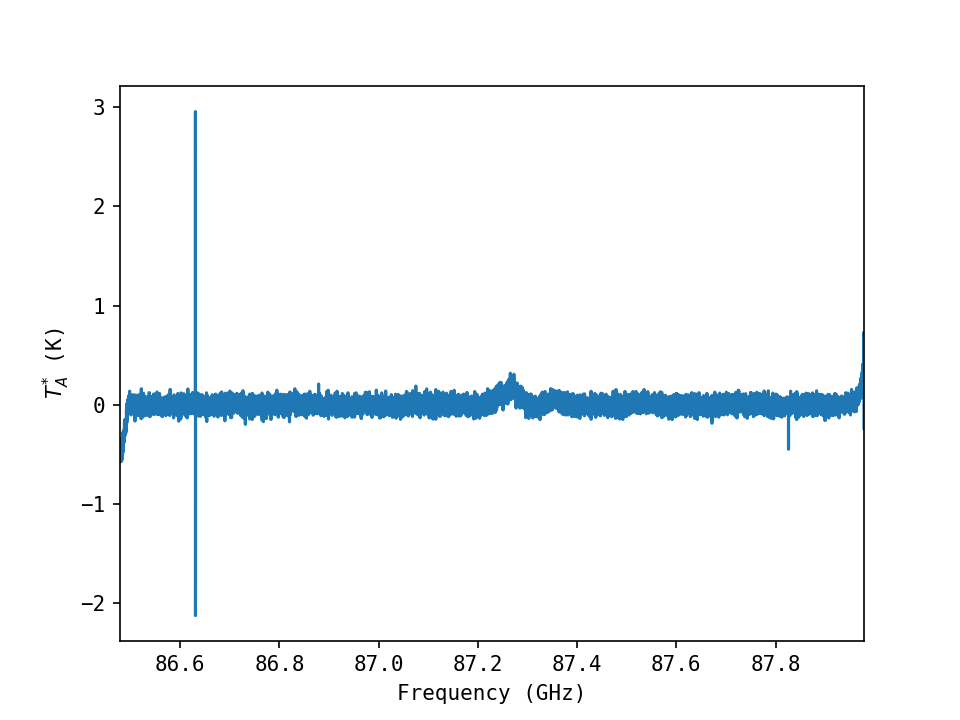

In [43]:
x = data["spectral_axis"]*1e-9 # Convert to GHz.
y = np.ma.masked_where(data["mask"], data["flux"]) # We need to mask the flux values.
plt.figure(dpi=150)
plt.plot(x, y)
plt.ylabel(r"$T_{A}^{*}$ (K)")
plt.xlabel(r"Frequency (GHz)")
plt.show()

In [44]:
read_spec_smo.check_stats(0.04375961 * u.K)

16:01:00.450 I Note: found 92 NaN (masked) values


16:01:00.451 I rms is OK 


In [45]:
# radiometer on one pre-Ta* corrected window
nod_ta[0,0][2000:7000].radiometer(roll=1)  # 1.0398

16:01:00.955 I Note: found 20 NaN (masked) values


np.float64(1.0398178385707268)